# Final Data Cleaning

## Load Dataset

In [1]:
import pandas as pd

INPUT_FILE = "classified_all_tweets_final_v2.csv"

df = pd.read_csv(INPUT_FILE)

print(df.shape)
print(df.columns)
df.head()

(11866, 9)
Index(['row_id', 'tweet_id', 'tweet', 'topic', 'stance', 'confidence',
       'short_justification', 'date', 'politician'],
      dtype='str')


,row_id,tweet_id,tweet,topic,stance,confidence,short_justification,date,politician
0,0,1517820080431767552,"Un día como hoy sentimos cerca la cultura, la ...",Other,Neutral,0.95,"Celebratory message for regional holidays, no ...",2022-04-23,NunezFeijoo
1,1,1518145232067604484,"Si viva el @RealBetis manque pierda, cuando ga...",Other,Neutral,0.95,Congratulatory message regarding a sports event.,2022-04-24,NunezFeijoo
2,2,1518231878616195072,É unha honra ser pregoeiro da LIV Festa do Coc...,Other,Neutral,0.95,Descriptive message about a local cultural fes...,2022-04-24,NunezFeijoo
3,3,1518312850133037058,Francia ha decido seguir por el camino de la e...,International Affairs,In favor,0.95,Explicit support for Emmanuel Macron and his p...,2022-04-24,NunezFeijoo
4,4,1518662521623912451,.@JuanMa_Moreno ha demostrado que es el mejor ...,National Politics and Governance,In favor,0.95,Explicit support for Juanma Moreno and his pol...,2022-04-25,NunezFeijoo


As we can see. the final LLM-classified dataset contains 11866 rows and 9 columns before cleaning.

## Error check

In [2]:
error_mask = (
    (df["stance"] == "ERROR") |
    (df["topic"] == "ERROR")
)

error_count = error_mask.sum()
error_rate = error_count / len(df) * 100

print("Error count:", error_count)
print("Error rate:", round(error_rate, 3), "%")

Error count: 0
Error rate: 0.0 %


In [3]:
df_clean = df[~error_mask].copy()

## Valid Values

### Topics and Stance

In [4]:
valid_topics = [
    "Economy and Employment",
    "Welfare, Housing and Social Policy",
    "National Politics and Governance",
    "International Affairs",
    "Immigration and Security",
    "Rights and Equality",
    "Other",
]

valid_stances = [
    "In favor",
    "Against",
    "Neutral",
    "Unclear",
]

invalid_topics = df_clean[~df_clean["topic"].isin(valid_topics)]
invalid_stances = df_clean[~df_clean["stance"].isin(valid_stances)]

print("Invalid topics:", len(invalid_topics))
print("Invalid stances:", len(invalid_stances))

Invalid topics: 0
Invalid stances: 0


In [5]:
topic_counts = df_clean["topic"].value_counts()
topic_percent = df_clean["topic"].value_counts(normalize=True) * 100

topic_distribution = pd.DataFrame({
    "count": topic_counts,
    "percent": topic_percent.round(2)
})

topic_distribution

,count,percent
topic,,
National Politics and Governance,4367,36.80
Economy and Employment,2038,17.18
International Affairs,1738,14.65
Other,1576,13.28
"Welfare, Housing and Social Policy",931,7.85
Rights and Equality,771,6.50
Immigration and Security,445,3.75


In [6]:
stance_counts = df_clean["stance"].value_counts()
stance_percent = df_clean["stance"].value_counts(normalize=True) * 100

stance_distribution = pd.DataFrame({
    "count": stance_counts,
    "percent": stance_percent.round(2)
})

stance_distribution

,count,percent
stance,,
In favor,6886,58.03
Against,3290,27.73
Neutral,1159,9.77
Unclear,531,4.47


### Duplicates

In [7]:
print("Duplicated tweet_id:", df_clean["tweet_id"].duplicated().sum())
print("Duplicated tweet text:", df_clean["tweet"].duplicated().sum())

Duplicated tweet_id: 0
Duplicated tweet text: 0


### Dates

In [8]:
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

missing_dates = df_clean["date"].isna().sum()

print("Missing or invalid dates:", missing_dates)
print("Min date:", df_clean["date"].min())
print("Max date:", df_clean["date"].max())

Missing or invalid dates: 0
Min date: 2022-04-23 00:00:00
Max date: 2026-04-22 00:00:00


In [9]:
df_clean["year"] = df_clean["date"].dt.year
df_clean["month"] = df_clean["date"].dt.to_period("M").astype(str)
df_clean["quarter"] = df_clean["date"].dt.to_period("Q").astype(str)

### Politicians

In [10]:
df_clean["politician"].value_counts()

politician
Yolanda_Diaz_      3547
sanchezcastejon    3074
NunezFeijoo        2889
Santi_ABASCAL      2356
Name: count, dtype: int64

### Temporal coverage by political actor

Before conducting actor-level comparisons, it is necessary to inspect the temporal coverage of each political actor. This is especially important because not all actors are active on X during the entire study period.

Uneven temporal coverage does not represent a classification error, but a limitation of the data source. Since the study analyzes political discourse as expressed on X, the absence of posts after a certain date should be interpreted as absence of activity on this platform, not as absence of political communication in general.

In [11]:
actor_temporal_coverage = (
    df_clean
    .groupby("politician")
    .agg(
        n_tweets=("tweet_id", "count"),
        min_date=("date", "min"),
        max_date=("date", "max")
    )
    .reset_index()
)

actor_temporal_coverage

,politician,n_tweets,min_date,max_date
0,NunezFeijoo,2889,2022-04-23,2026-04-22
1,Santi_ABASCAL,2356,2022-04-23,2026-04-22
2,Yolanda_Diaz_,3547,2022-04-23,2025-01-21
3,sanchezcastejon,3074,2022-04-23,2026-04-22


In [12]:
actor_temporal_coverage.to_csv(
    "actor_temporal_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

The following table and plot show the number of tweets per month for each political actor. This helps identify periods with missing or low activity and prevents biased temporal comparisons.

In [13]:
monthly_actor_counts = (
    df_clean
    .groupby(["month", "politician"])
    .size()
    .reset_index(name="n_tweets")
)

monthly_actor_counts.head()

,month,politician,n_tweets
0,2022-04,NunezFeijoo,20
1,2022-04,Santi_ABASCAL,7
2,2022-04,Yolanda_Diaz_,29
3,2022-04,sanchezcastejon,20
4,2022-05,NunezFeijoo,61


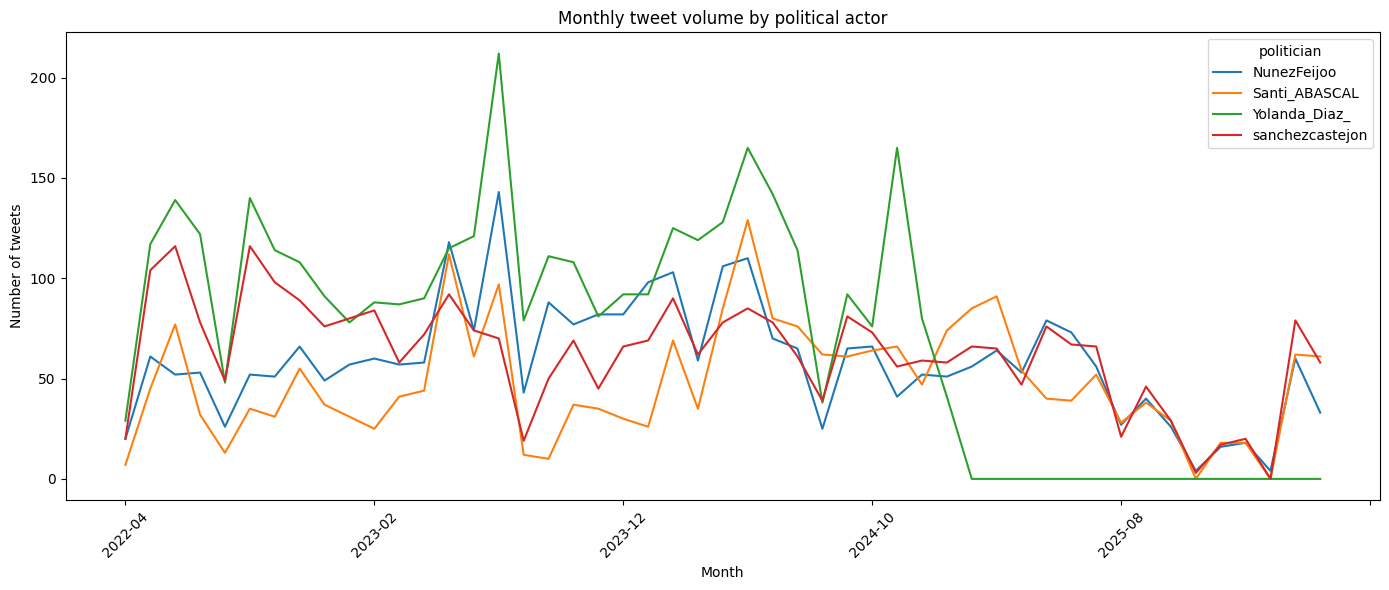

In [14]:
import matplotlib.pyplot as plt

monthly_actor_pivot = monthly_actor_counts.pivot(
    index="month",
    columns="politician",
    values="n_tweets"
).fillna(0)

monthly_actor_pivot.plot(figsize=(14, 6))

plt.title("Monthly tweet volume by political actor")
plt.xlabel("Month")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
monthly_actor_counts.to_csv(
    "monthly_actor_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

### Common activity period

Because the actors do not necessarily have the same temporal coverage, a common activity period is defined for strict actor-level comparisons. This avoids comparing actors during months in which one of them was not active on X.

The full dataset is still retained for descriptive analysis, while the common-period subset is used when direct temporal comparisons between actors are required.

In [16]:
common_start = df_clean.groupby("politician")["date"].min().max()
common_end = df_clean.groupby("politician")["date"].max().min()

print("Common start:", common_start)
print("Common end:", common_end)

df_common = df_clean[
    (df_clean["date"] >= common_start) &
    (df_clean["date"] <= common_end)
].copy()

print("Full dataset rows:", len(df_clean))
print("Common-period rows:", len(df_common))

Common start: 2022-04-23 00:00:00
Common end: 2025-01-21 00:00:00
Full dataset rows: 11866
Common-period rows: 9908


In [17]:
df_common.to_csv(
    "classified_all_tweets_final_v2_common_period.csv",
    index=False,
    encoding="utf-8-sig"
)

### Methodological decision

Two analytical datasets are retained:

1. `df_clean`: the full cleaned dataset, used for descriptive analyses of the complete available corpus.
2. `df_common`: the common-period dataset, used for strict actor-level temporal comparisons.

No missing activity is imputed. Months without tweets for a given actor are treated as absence of activity on X, not as absence of political communication in general.

### Confidence

In [18]:
df_clean["confidence"].describe()

count    11866.000000
mean         0.922358
std          0.075823
min          0.600000
25%          0.950000
50%          0.950000
75%          0.950000
max          0.950000
Name: confidence, dtype: float64

The LLM pipeline originally returned a `confidence` score between 0 and 1 for each classification. However, after inspecting its distribution in the final classified dataset, the variable showed poor calibration and very limited analytical usefulness.

These results show that the distribution is highly concentrated at the upper bound, with at least 75% of the observations receiving a confidence score of 0.95. This indicates that the model tends to assign very high confidence values regardless of potential ambiguity in the classification task.

For this reason, the `confidence` variable is not treated as a reliable probability estimate or uncertainty measure. It is excluded from the analytical dataset and is not used for filtering, weighting, visualization, or interpretation of results.

This decision does not affect the main variables of interest (`topic` and `stance`), which remain the focus of the analysis.


In [19]:
df_clean_with_confidence = df_clean.copy()
df_clean = df_clean.drop(columns=["confidence"])
df_common = df_common.drop(columns=["confidence"])

## Politician-topic analysis

### Full period

In [20]:
actor_topic_counts = pd.crosstab(
    df_clean["politician"],
    df_clean["topic"]
)

actor_topic_percent = pd.crosstab(
    df_clean["politician"],
    df_clean["topic"],
    normalize="index"
) * 100

actor_topic_counts
actor_topic_percent.round(2)

topic,Economy and Employment,Immigration and Security,International Affairs,National Politics and Governance,Other,Rights and Equality,"Welfare, Housing and Social Policy"
politician,,,,,,,
NunezFeijoo,9.66,2.42,8.79,53.96,15.26,2.84,7.06
Santi_ABASCAL,5.48,13.03,13.71,54.24,8.28,2.67,2.59
Yolanda_Diaz_,32.11,0.73,9.25,23.60,13.87,9.81,10.63
sanchezcastejon,15.97,1.37,27.10,22.54,14.57,9.04,9.40


In [21]:
actor_topic_counts.to_csv("actor_topic_counts.csv")
actor_topic_percent.to_csv("actor_topic_percent.csv")

### Common period

In [22]:
actor_topic_counts_common = pd.crosstab(
    df_common["politician"],
    df_common["topic"]
)

actor_topic_percent_common = pd.crosstab(
    df_common["politician"],
    df_common["topic"],
    normalize="index"
) * 100

actor_topic_percent_common.round(2)

topic,Economy and Employment,Immigration and Security,International Affairs,National Politics and Governance,Other,Rights and Equality,"Welfare, Housing and Social Policy"
politician,,,,,,,
NunezFeijoo,9.80,1.86,8.20,54.21,16.09,2.88,6.96
Santi_ABASCAL,6.35,10.95,13.16,56.44,7.92,2.85,2.33
Yolanda_Diaz_,32.11,0.73,9.25,23.60,13.87,9.81,10.63
sanchezcastejon,17.29,1.47,25.80,22.86,14.41,8.67,9.51


In [23]:
actor_topic_counts_common.to_csv("actor_topic_counts_common_period.csv")
actor_topic_percent_common.to_csv("actor_topic_percent_common_period.csv")

## Politician-stance analysis

### Full period

In [24]:
actor_stance_counts = pd.crosstab(
    df_clean["politician"],
    df_clean["stance"]
)

actor_stance_percent = pd.crosstab(
    df_clean["politician"],
    df_clean["stance"],
    normalize="index"
) * 100

actor_stance_percent.round(2)

stance,Against,In favor,Neutral,Unclear
politician,,,,
NunezFeijoo,41.68,42.23,14.12,1.97
Santi_ABASCAL,57.64,29.97,4.46,7.94
Yolanda_Diaz_,10.29,73.89,9.56,6.26
sanchezcastejon,11.81,76.09,9.99,2.11


In [25]:
actor_stance_counts.to_csv("actor_stance_counts.csv")
actor_stance_percent.to_csv("actor_stance_percent.csv")

### Common period

In [26]:
actor_stance_counts_common = pd.crosstab(
    df_common["politician"],
    df_common["stance"]
)

actor_stance_percent_common = pd.crosstab(
    df_common["politician"],
    df_common["stance"],
    normalize="index"
) * 100

actor_stance_percent_common.round(2)

stance,Against,In favor,Neutral,Unclear
politician,,,,
NunezFeijoo,38.79,44.99,14.54,1.68
Santi_ABASCAL,54.69,31.97,4.78,8.56
Yolanda_Diaz_,10.29,73.89,9.56,6.26
sanchezcastejon,10.05,78.56,9.55,1.84


In [27]:
actor_stance_counts_common.to_csv("actor_stance_counts_common_period.csv")
actor_stance_percent_common.to_csv("actor_stance_percent_common_period.csv")

# Basic Temporal Analysis

The following temporal analysis is based on the full cleaned dataset. Actor-level temporal comparisons should be interpreted in light of the unequal temporal coverage identified above.

## Temporal Check

In [28]:
monthly_counts = df_clean.groupby("month").size()

monthly_counts.describe()

count     49.000000
mean     242.163265
std      116.533498
min        4.000000
25%      164.000000
50%      253.000000
75%      316.000000
max      522.000000
dtype: float64

<Axes: xlabel='month'>

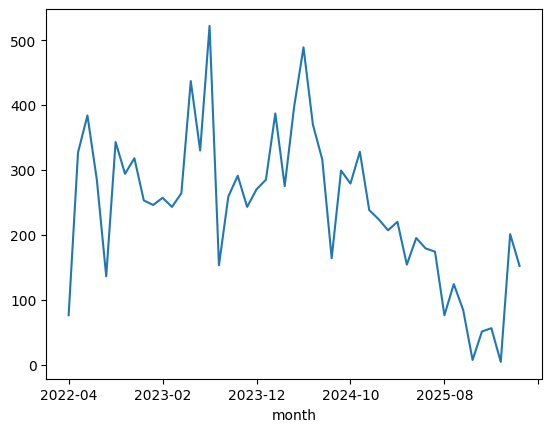

In [29]:
monthly_counts.plot()

In [30]:
monthly_actor_counts = df_clean.groupby(["month", "politician"]).size().reset_index(name="count")
monthly_topic_counts = df_clean.groupby(["month", "topic"]).size().reset_index(name="count")

In [31]:
monthly_counts.to_csv("monthly_counts.csv")
monthly_actor_counts.to_csv("monthly_actor_counts.csv", index=False)
monthly_topic_counts.to_csv("monthly_topic_counts.csv", index=False)

# Other values

In [32]:
other_df = df_clean[df_clean["topic"] == "Other"]

print(len(other_df))
print(f'{len(other_df) / len(df_clean) * 100:.2f}%')

other_df.sample(20, random_state=42)[["tweet", "stance", "short_justification"]]


1576
13.28%


,tweet,stance,short_justification
9666,Emotiva e impresionante. La vida de Lorca sobr...,Unclear,Review of a theatrical performance.
6279,Hoxe perdemos a un loitador incansable pola de...,Neutral,Tribute to a deceased labor activist; expresse...
9149,Emocionado paseo por la ciudad vieja de Quito ...,Neutral,Personal observation about a visit to Quito.
4033,#EuropaVIVA24 #VOX #Viva24,Unclear,"Contains only hashtags, no clear opinion expre..."
3573,Esta tarde a las 20 horas en Mérida #Mérida #V...,Unclear,Informational post about a campaign event.
11570,Vuelvo a hacer un llamamiento a la precaución....,Neutral,Warning about wildfire risks and gratitude to ...
3666,Orgullosos de nuestras Fuerzas Armadas. Orgull...,In favor,Expresses pride in Spanish history and institu...
1559,He venido a Valencia para agradecer a los bomb...,Neutral,Expresses gratitude to emergency workers and l...
3449,¡Gracias Cartagena!#Cartagena #CuidaLotuyo#VOX...,Unclear,Expression of gratitude for a campaign event.
229,Bona Diada. Feliz día de Cataluña a todos.,Neutral,A standard holiday greeting.


# Final Dataset

In [33]:
OUTPUT_FILE = "classified_all_tweets_final_v2_clean.csv"

df_clean.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print("Saved:", OUTPUT_FILE)
print("Rows:", len(df_clean))

Saved: classified_all_tweets_final_v2_clean.csv
Rows: 11866


In [34]:
summary = {
    "raw_rows": len(df),
    "clean_rows": len(df_clean),
    "reclassified_errors": 25,                 # documentado, no eliminado
    "errors": int(error_mask.sum()), # debería ser 0
    "date_min": df_clean["date"].min(),
    "date_max": df_clean["date"].max(),
    "months_covered": df_clean["month"].nunique(),
    "months_with_lt_30_tweets": int((df_clean.groupby("month").size() < 30).sum()),
    "n_politicians": df_clean["politician"].nunique(),
    "tweets_per_politician": df_clean["politician"].value_counts().to_dict(),
    "n_topics": df_clean["topic"].nunique(),
    "n_stances": df_clean["stance"].nunique(),
    "other_share_percent": round((df_clean["topic"]=="Other").mean()*100, 2),
    "unclear_share_percent": round((df_clean["stance"]=="Unclear").mean()*100, 2),
    "model_name": "gemini-3.1-flash-lite-preview",
    "prompt_version": "v2",
}
summary_df = pd.DataFrame([summary])
summary_df

,raw_rows,clean_rows,reclassified_errors,errors,date_min,date_max,months_covered,months_with_lt_30_tweets,n_politicians,tweets_per_politician,n_topics,n_stances,other_share_percent,unclear_share_percent,model_name,prompt_version
0,11866,11866,25,0,2022-04-23,2026-04-22,49,2,4,"{'Yolanda_Diaz_': 3547, 'sanchezcastejon': 307...",7,4,13.28,4.47,gemini-3.1-flash-lite-preview,v2
